In [1]:
import pandas as pd
import numpy as np
from data_loader import DataLoader
from feature_generator import FeatureGenerator
from label_generator import LabelGenerator
from regression_model_trainer import RegressionModelTrainer
from classifier_model_trainer import ClassifierModelTrainer
from data_processor import DataProcessor


In [2]:
# ✅ Load CSV
loader = DataLoader()
training_df_raw = loader.load_from_csv("data/training/mes_2_new.csv")  # change filename accordingly

# ✅ Drop any duplicate timestamps
training_df_raw = training_df_raw.drop_duplicates(subset=["Date", "Time"])

training_df_raw.head()


Data successfully loaded from data/training/mes_2_new.csv


,Open,High,Low,Close,Volume,Date,Time
0,6137.50,6142.75,6135.75,6142.25,0,11/28/2024,1:05
1,6142.25,6143.75,6141.50,6141.50,993,11/28/2024,1:10
2,6141.75,6142.25,6140.00,6141.25,549,11/28/2024,1:15
3,6141.00,6141.25,6139.75,6140.75,221,11/28/2024,1:20
4,6141.00,6142.50,6141.00,6141.75,386,11/28/2024,1:25


In [3]:
feature_generator = FeatureGenerator()
training_df_features = feature_generator.create_all_features(training_df_raw)

training_df_features.head()


✅ FeatureGenerator initialized!
🚀 Starting full feature generation pipeline...
✅ Successfully calculated all technical indicators with correct column names!
✅ VWAP added successfully!
✅ Fibonacci levels added successfully! (Length=50, Retrace=0.382)
🔹 Computing CCI with length=14...
✅ Successfully computed CCI and CCI_Avg (CCI: 14, CCI_Avg: 9)
✅ Ichimoku Cloud indicators added successfully!
✅ Successfully computed ATR and added ATR-adjusted price features!
✅ Added EMAs (5-50) and their Distances (Close/Open) Successfully!
✅ Successfully added High-Based Indicators (Unified Method)!
✅ Added constant columns: ['OverBot', 'OverSld', 'OverBought', 'OverSold', 'Zero Cross', 'CROSS FIB.1', 'CROSS FIB.2']
✅ Successfully added MACD indicators!
✅ Successfully added volatility, Williams %R, and Relative Volume features!
✅ Feature generation complete! Final DataFrame: 117 columns


,Open,High,Low,Close,Volume,Date,Time,FastAvg,SlowAvg,FastEMA,...,OverBought,OverSold,Zero Cross,CROSS FIB.1,CROSS FIB.2,MACD,MACDAvg,MACDDiff,Williams_R,Relative_Volume
0,6137.50,6142.75,6135.75,6142.25,0,11/28/2024,1:05,NaN,NaN,6142.2500,...,70,30,0,0,0,0.000000,0.000000,0.000000,NaN,NaN
1,6142.25,6143.75,6141.50,6141.50,993,11/28/2024,1:10,NaN,NaN,6142.1000,...,70,30,0,0,0,-0.059829,-0.011966,-0.047863,NaN,NaN
2,6141.75,6142.25,6140.00,6141.25,549,11/28/2024,1:15,NaN,NaN,6141.9300,...,70,30,0,0,0,-0.125965,-0.034766,-0.091199,NaN,NaN
3,6141.00,6141.25,6139.75,6140.75,221,11/28/2024,1:20,NaN,NaN,6141.6940,...,70,30,0,0,0,-0.216231,-0.071059,-0.145172,NaN,NaN
4,6141.00,6142.50,6141.00,6141.75,386,11/28/2024,1:25,NaN,NaN,6141.7052,...,70,30,0,0,0,-0.204717,-0.097790,-0.106926,NaN,NaN


In [4]:
label_generator = LabelGenerator()
training_df_labeled = label_generator.elasticnet_label_next_high(training_df_features)


✅ Elastic Net label 'Next_High' added.


In [5]:
trainer = RegressionModelTrainer(
    include_prices=False,         # Set to True if you want price columns
    apply_filter=True,            # Filter based on error threshold
    filter_threshold=4.0          # Can adjust this value
)

trainer.prepare_data(training_df_features)
trainer.train_model()
trainer.make_predictions()



✅ Sample Data Alignment Check:
   Sample Target (y_test)  Corresponding Feature Row
0                 5893.50                       8116
1                 5893.50                       8117
2                 5891.75                       8118
3                 5892.75                       8119
4                 5892.75                       8120


C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.601e+03, tolerance: 6.173e+03
  model = cd_fast.enet_coordinate_descent(


In [6]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(trainer.y_test, trainer.predictions)
r2 = r2_score(trainer.y_test, trainer.predictions)

print("📊 Regression Metrics (Unfiltered):")
print(f"MSE: {mse:.3f}")
print(f"R²: {r2:.3f}")
print(f"Test Samples: {len(trainer.y_test)}")
print(f"Features Used: {trainer.x_train.shape[1]}")


📊 Regression Metrics (Unfiltered):
MSE: 3.620
R²: 0.999
Test Samples: 2029
Features Used: 111


In [7]:
# Make a full copy before modifying to avoid SettingWithCopyWarning
training_df_labeled = training_df_labeled.copy()

# Safely create and set Timestamp index
training_df_labeled["Timestamp"] = pd.to_datetime(training_df_labeled["Date"] + " " + training_df_labeled["Time"])
training_df_labeled = training_df_labeled.set_index("Timestamp").sort_index()


In [8]:
# ✅ Step 1: Reset index to allow access by integer
training_df_labeled = training_df_labeled.reset_index(drop=True)

# ✅ Step 2: Clip x_test indices to max valid row index (prevent KeyError)
max_valid_index = len(training_df_labeled) - 1
safe_indices = trainer.x_test.index[trainer.x_test.index <= max_valid_index]

# ✅ Optional: Warn if any were dropped
if len(safe_indices) < len(trainer.x_test.index):
    print(f"⚠️ {len(trainer.x_test.index) - len(safe_indices)} test rows dropped due to index overflow.")

# ✅ Step 3: Build x_test_with_meta with safe indices only
x_test_with_meta = trainer.x_test.loc[safe_indices].copy()

# Add Date and Time using safe indices
x_test_with_meta["Date"] = training_df_labeled.loc[safe_indices, "Date"].values
x_test_with_meta["Time"] = training_df_labeled.loc[safe_indices, "Time"].values

# Create Timestamp index
x_test_with_meta["Timestamp"] = pd.to_datetime(x_test_with_meta["Date"] + " " + x_test_with_meta["Time"])
x_test_with_meta = x_test_with_meta.set_index("Timestamp").sort_index()

# ✅ Step 4: Rebuild training_df_labeled with Timestamp index (only once!)
training_df_labeled["Timestamp"] = pd.to_datetime(training_df_labeled["Date"] + " " + training_df_labeled["Time"])
training_df_labeled = training_df_labeled.set_index("Timestamp").sort_index()

# ✅ Step 5: Join OHLC columns
trainer.x_test_with_meta = x_test_with_meta.join(
    training_df_labeled[["Open", "High", "Low", "Close"]],
    how="left"
)

# ✅ Step 6: Add predictions and shifted columns
trainer.x_test_with_meta["Predicted_High"] = trainer.predictions[:len(trainer.x_test_with_meta)]
trainer.x_test_with_meta["Prev_Close"] = trainer.x_test_with_meta["Close"].shift(1)
trainer.x_test_with_meta["Prev_Predicted_High"] = trainer.x_test_with_meta["Predicted_High"].shift(1)

# ✅ Step 7: Clean result
df_with_meta = trainer.x_test_with_meta.dropna(subset=["Prev_Close", "Prev_Predicted_High"])

print("✅ Metadata attached and df_with_meta ready. Shape:", df_with_meta.shape)


⚠️ 1 test rows dropped due to index overflow.
✅ Metadata attached and df_with_meta ready. Shape: (2027, 119)


In [9]:
# Step 1: Attach predictions directly to df
df_for_labeling = trainer.x_test_with_meta.copy()
df_for_labeling["Predicted_High"] = trainer.predictions[:len(df_for_labeling)]

# Step 2: Shift predictions and closes for labeling logic
df_for_labeling["Prev_Predicted_High"] = df_for_labeling["Predicted_High"].shift(1)
df_for_labeling["Prev_Close"] = df_for_labeling["Close"].shift(1)

# Step 3: Drop NaNs due to shifting
df_for_labeling = df_for_labeling.dropna(subset=["Prev_Close", "Prev_Predicted_High"])

# Step 4: Correct labeling
df_labeled_old = label_generator.add_good_bar_label(df_for_labeling)
df_labeled_all = label_generator.long_good_bar_label_all(df_for_labeling)
df_labeled_bullish = label_generator.long_good_bar_label_bullish_only(df_for_labeling)


✅ Successfully assigned labels without -1!
✅ All-bar long label applied (1 = bullish + actual ≥ predicted).
✅ Bullish-only label applied (1 = actual ≥ predicted).


In [10]:

from imblearn.over_sampling import SMOTE

processor = DataProcessor()

# 🔵 old version
X_train_old, y_train_old, X_test_old, y_test_old = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_old,
    target_column="good_bar_prediction_outside_of_boundary",
    drop_target=True,
    split_ratio=0.8
)
smote_old = SMOTE(random_state=42)

classifier_X_train_bal_old, classifier_y_train_bal_old = smote_old.fit_resample(X_train_old, y_train_old)
classifier_trainer_old = ClassifierModelTrainer()
classifier_trainer_old.train_all_classifiers(classifier_X_train_bal_old, classifier_y_train_bal_old, X_test_old, y_test_old, trainer)


smote_all = SMOTE(random_state=42)

# 🔵 All-bar version
X_train_all, y_train_all, X_test_all, y_test_all = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

classifier_X_train_bal_all, classifier_y_train_bal_all = smote_all.fit_resample(X_train_all, y_train_all)
classifier_trainer_all = ClassifierModelTrainer()
classifier_trainer_all.train_all_classifiers(classifier_X_train_bal_all, classifier_y_train_bal_all, X_test_all, y_test_all, trainer)


smote_bullish = SMOTE(random_state=42)

# 🟣 Bullish-only version
X_train_bullish, y_train_bullish, X_test_bullish, y_test_bullish = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)
classifier_X_train_bal_bullish, classifier_y_train_bal_bullish = smote_bullish.fit_resample(X_train_bullish, y_train_bullish)
classifier_trainer_bullish = ClassifierModelTrainer()
classifier_trainer_bullish.train_all_classifiers(classifier_X_train_bal_bullish, classifier_y_train_bal_bullish, X_test_bullish, y_test_bullish, trainer)



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-21 07:35:00
1                       1       2025-01-21 07:40:00
2                       1       2025-01-21 07:45:00
3                       0       2025-01-21 07:50:00
4                       0       2025-01-21 07:55:00
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.79      0.88      0.84       179
           1       0.90      0.82      0.86       227

    accuracy                           0.85       406
   macro avg       0.85      0.85      0.85       406
weighted avg       0.85      0.85      0.85       406


🎯 RandomForest Accuracy: 0.8473

🚀 Training LightGBM...

📊 LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       179
           1  


# Classifier Analysis

Total Bars: 2023
Total 'Good' Labeled Bars (Potential Trades): 980 (48.44%)

📅 Potential trades per day statistics:
count      8.000000
mean     122.500000
std       16.335763
min       96.000000
25%      113.250000
50%      125.000000
75%      132.000000
max      143.000000
dtype: float64


C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\3236097199.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_bars['Date'] = pd.to_datetime(good_bars['Date'])
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


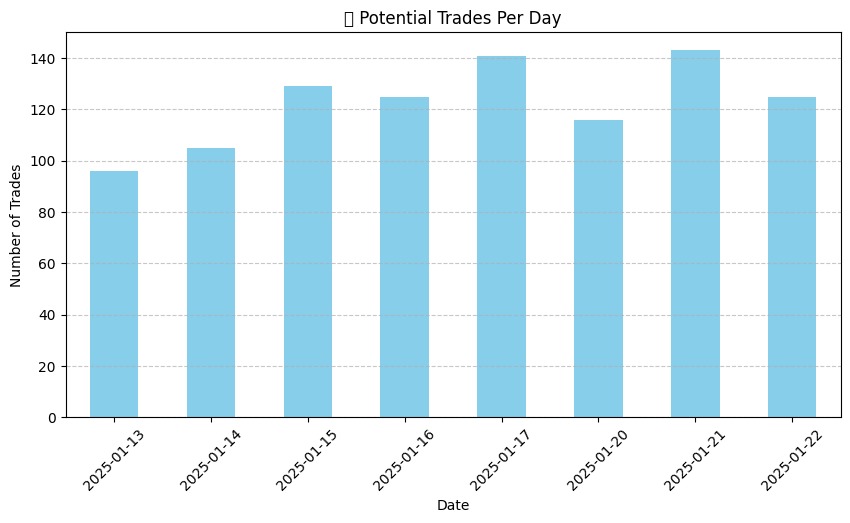

C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\3236097199.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  good_bars['Hour'] = pd.to_datetime(good_bars['Time']).dt.hour
C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\3236097199.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_bars['Hour'] = pd.to_datetime(good_bars['Time']).dt.hour
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



⏰ Trades distribution by hour:
Hour
0      2
1     39
2     40
3     42
4     43
5     44
6     50
7     47
8     50
9     50
10    51
11    47
12    55
13    43
14    43
15    41
16    42
17    45
18    37
19    43
20    30
21    36
22    43
23    17
dtype: int64


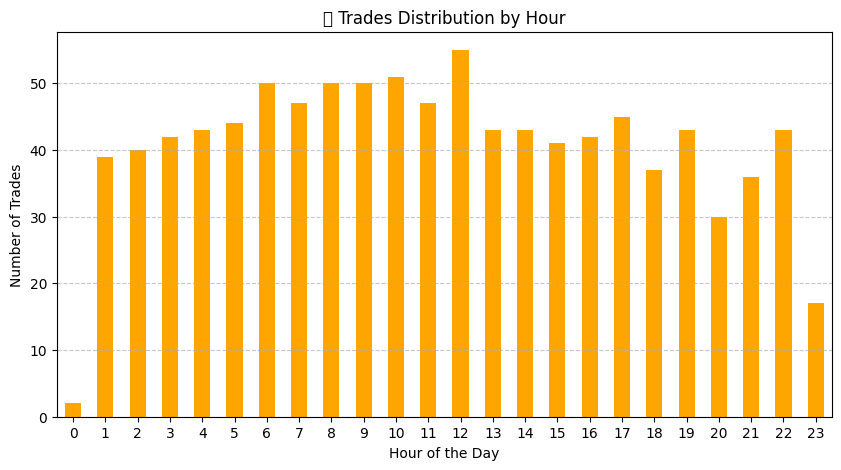

In [11]:
import matplotlib.pyplot as plt

# Check distribution of labels in the bullish-only labeled dataset
good_bars = df_labeled_bullish[df_labeled_bullish["long_good_bar_label"] == 1]

total_bars = len(df_labeled_bullish)
total_good_bars = len(good_bars)
percentage_good = (total_good_bars / total_bars) * 100

print(f"Total Bars: {total_bars}")
print(f"Total 'Good' Labeled Bars (Potential Trades): {total_good_bars} ({percentage_good:.2f}%)\n")

# Count potential trades per day
good_bars['Date'] = pd.to_datetime(good_bars['Date'])
trades_per_day = good_bars.groupby(good_bars['Date'].dt.date).size()

print("📅 Potential trades per day statistics:")
print(trades_per_day.describe())

# Simple visualization of potential trades per day
plt.figure(figsize=(10, 5))
trades_per_day.plot(kind='bar', color='skyblue')
plt.title('📅 Potential Trades Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Trades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

# Check timing distribution (hours)
good_bars['Hour'] = pd.to_datetime(good_bars['Time']).dt.hour
trades_by_hour = good_bars.groupby('Hour').size()

print("\n⏰ Trades distribution by hour:")
print(trades_by_hour)

# Visualization of trades by hour
plt.figure(figsize=(10, 5))
trades_by_hour.plot(kind='bar', color='orange')
plt.title('⏰ Trades Distribution by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trades')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()


In [12]:
from sklearn.metrics import classification_report

# Label variants and their associated trainers/datasets
variants = {
    "Old": {
        "trainer": classifier_trainer_old,
        "X_train": X_train_old,
        "y_train": y_train_old,
        "X_test": X_test_old,
        "y_test": y_test_old,
    },
    "All": {
        "trainer": classifier_trainer_all,
        "X_train": X_train_all,
        "y_train": y_train_all,
        "X_test": X_test_all,
        "y_test": y_test_all,
    },
    "Bullish": {
        "trainer": classifier_trainer_bullish,
        "X_train": X_train_bullish,
        "y_train": y_train_bullish,
        "X_test": X_test_bullish,
        "y_test": y_test_bullish,
    },
}

print("🔍 Checking for overfitting and data leakage across all label types:\n")

for label_name, data in variants.items():
    print(f"🏷️ Label Variant: {label_name}")
    models = {
        'RandomForest': data["trainer"].rf_results["model"],
        'LightGBM': data["trainer"].lgbm_results["model"],
        'XGBoost': data["trainer"].xgb_results["model"]
    }

    for name, model in models.items():
        print(f"\nModel: {name}")

        # Predictions on training and test
        if name in ['LightGBM', 'XGBoost']:
            train_preds = (model.predict(data["X_train"]) >= 0.5).astype(int)
            test_preds = (model.predict(data["X_test"]) >= 0.5).astype(int)
        else:
            train_preds = model.predict(data["X_train"])
            test_preds = model.predict(data["X_test"])

        # Reports
        train_report = classification_report(data["y_train"], train_preds, digits=2, output_dict=True)
        test_report = classification_report(data["y_test"], test_preds, digits=2, output_dict=True)

        print("  ➡️ Training vs. Testing Performance (Precision, Recall, F1):")
        print(f"    - Train: {train_report['1']['precision']:.2f}, {train_report['1']['recall']:.2f}, {train_report['1']['f1-score']:.2f}")
        print(f"    - Test:  {test_report['1']['precision']:.2f}, {test_report['1']['recall']:.2f}, {test_report['1']['f1-score']:.2f}")

        # Check for gap
        precision_gap = abs(train_report['1']['precision'] - test_report['1']['precision'])
        recall_gap = abs(train_report['1']['recall'] - test_report['1']['recall'])
        f1_gap = abs(train_report['1']['f1-score'] - test_report['1']['f1-score'])

        if precision_gap > 0.1 or recall_gap > 0.1 or f1_gap > 0.1:
            print("  ⚠️ Potential overfitting or data leakage detected!")
        else:
            print("  ✅ No significant signs of overfitting or leakage.")

    print("\n" + "=" * 65 + "\n")


🔍 Checking for overfitting and data leakage across all label types:

🏷️ Label Variant: Old

Model: RandomForest
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.95, 0.96, 0.96
    - Test:  0.90, 0.82, 0.86
  ⚠️ Potential overfitting or data leakage detected!

Model: LightGBM
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 1.00, 1.00, 1.00
    - Test:  0.91, 0.88, 0.90
  ⚠️ Potential overfitting or data leakage detected!

Model: XGBoost
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 1.00, 1.00, 1.00
    - Test:  0.92, 0.86, 0.89
  ⚠️ Potential overfitting or data leakage detected!


🏷️ Label Variant: All

Model: RandomForest
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 0.95, 0.96, 0.96
    - Test:  0.90, 0.82, 0.86
  ⚠️ Potential overfitting or data leakage detected!

Model: LightGBM
  ➡️ Training vs. Testing Performance (Precision, Recall, F1):
    - Train: 1.00, 1.00, 1

# Overfitting check and analysis

In [13]:
# Sanity check for overlapping indexes between training and testing sets (all label types)
variants = {
    "Old": (X_train_old, X_test_old),
    "All": (X_train_all, X_test_all),
    "Bullish": (X_train_bullish, X_test_bullish),
}

print("🔎 Checking for overlapping indexes (potential data leakage):\n")

for label_name, (X_train, X_test) in variants.items():
    overlap_index = X_train.index.intersection(X_test.index)

    if len(overlap_index) > 0:
        print(f"⚠️ {label_name}: Overlapping indexes found! Count = {len(overlap_index)}")
    else:
        print(f"✅ {label_name}: No overlapping indexes found.")


🔎 Checking for overlapping indexes (potential data leakage):

✅ Old: No overlapping indexes found.
✅ All: No overlapping indexes found.
✅ Bullish: No overlapping indexes found.


# CROSS VALIDATION BEFORE SMOTE

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Define label variants and their datasets
variants = {
    "Old": (X_train_old, y_train_old, X_test_old, y_test_old),
    "All": (X_train_all, y_train_all, X_test_all, y_test_all),
    "Bullish": (X_train_bullish, y_train_bullish, X_test_bullish, y_test_bullish),
}

# Base models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results = []
print("📊 Cross-Validation Results (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants.items():
    print(f"🔹 {variant_name.upper()} Label:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    for model_name, model_cls in model_classes.items():
        model = model_cls(random_state=42)
        y_pred = cross_val_predict(model, X_all, y_all, cv=5)

        report = classification_report(y_all, y_pred, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Convert to DataFrame if needed
cv_results_df = pd.DataFrame(cv_results)


📊 Cross-Validation Results (F1 + Precision for Label 1 and 0):

🔹 OLD Label:

  RandomForest: F1 = 0.666 | Precision (1) = 0.665 | Precision (0) = 0.687
  LightGBM: F1 = 0.668 | Precision (1) = 0.722 | Precision (0) = 0.686
  XGBoost: F1 = 0.730 | Precision (1) = 0.753 | Precision (0) = 0.741
------------------------------------------------------------
🔹 ALL Label:

  RandomForest: F1 = 0.679 | Precision (1) = 0.681 | Precision (0) = 0.699
  LightGBM: F1 = 0.675 | Precision (1) = 0.730 | Precision (0) = 0.692
  XGBoost: F1 = 0.734 | Precision (1) = 0.755 | Precision (0) = 0.746
------------------------------------------------------------
🔹 BULLISH Label:

  RandomForest: F1 = 0.658 | Precision (1) = 0.662 | Precision (0) = 0.679
  LightGBM: F1 = 0.660 | Precision (1) = 0.712 | Precision (0) = 0.679
  XGBoost: F1 = 0.720 | Precision (1) = 0.742 | Precision (0) = 0.732
------------------------------------------------------------


In [15]:
cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,Variant,Model,F1_Label_1,Precision_Label_1,Precision_Label_0
0,Old,RandomForest,0.665988,0.665310,0.686782
1,Old,LightGBM,0.667763,0.722420,0.685811
2,Old,XGBoost,0.730042,0.752979,0.740942
3,All,RandomForest,0.678608,0.680698,0.698955
4,All,LightGBM,0.675439,0.729858,0.692308
5,All,XGBoost,0.734416,0.754575,0.745902
6,Bullish,RandomForest,0.658111,0.662190,0.678673
7,Bullish,LightGBM,0.660099,0.711924,0.679422
8,Bullish,XGBoost,0.719916,0.742145,0.731818


In [16]:
# Modified version to show class distribution
for label_name, data in variants.items():
    if label_name in ["ALL", "BULLISH"]:  # Only show these two
        print(f"\n🔹 {label_name} Label Distribution:")
        print("Training set:")
        print(pd.Series(data["y_train"]).value_counts(normalize=True))
        print("\nTest set:")
        print(pd.Series(data["y_test"]).value_counts(normalize=True))

# Handling Class Imbalance

In [17]:
# !jupyter nbconvert --to script improving_classifiers.ipynb


In [18]:
# Install the imbalanced-learn package
!pip install imbalanced-learn

In [19]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, f1_score

print("📊 Class Imbalance Analysis and Handling\n")

# First let's examine the structure of the variants
variant_keys = list(variants.keys())
print(f"Available variant keys: {variant_keys}")

# Extract data from the first variant to understand its structure
first_key = variant_keys[0]
first_variant = variants[first_key]
print(f"Structure for {first_key}: {type(first_variant)}, length: {len(first_variant)}")

# Based on your previous code, I'm guessing the structure is:
# variants = {
#     "variant_name": (X_train, y_train, X_test, y_test),
#     ...
# }

# Let's check class distribution for relevant variants
for label_name in ["All", "Bullish"]:
    if label_name not in variants:
        print(f"Warning: {label_name} not found in variants")
        continue
        
    # Unpack the tuple
    X_train, y_train, X_test, y_test = variants[label_name]
    
    # Check class distribution
    class_counts = np.bincount(y_train)
    ratio = class_counts[1] / len(y_train) if len(class_counts) > 1 else 0
    
    print(f"🔹 {label_name} Label Distribution:")
    print(f"  Class 0 (negative): {class_counts[0]} ({(1-ratio)*100:.2f}%)")
    print(f"  Class 1 (positive): {class_counts[1]} ({ratio*100:.2f}%)")
    print(f"  Imbalance ratio: 1:{class_counts[0]/class_counts[1]:.1f}\n")

# Step 2: Define model creation functions with class balancing
def create_balanced_models():
    """Create model instances with class balancing techniques"""
    # Random Forest with balanced class weights
    rf_balanced = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
    
    # For XGBoost, we use scale_pos_weight parameter
    xgb_balanced = XGBClassifier(
        scale_pos_weight=5,  # Will be adjusted dynamically
        eval_metric='logloss',
        random_state=42
    )
    
    # For LightGBM, we use class_weight parameter
    lgbm_balanced = LGBMClassifier(
        class_weight='balanced',
        random_state=42
    )
    
    return {
        'RandomForest': rf_balanced,
        'XGBoost': xgb_balanced,
        'LightGBM': lgbm_balanced
    }

# Step 3: Evaluate models with both balancing approaches
results = {}

for label_name in ["All", "Bullish"]:
    if label_name not in variants:
        continue
        
    # Unpack the tuple
    X_train, y_train, X_test, y_test = variants[label_name]
    
    print(f"🔹 {label_name.upper()} Label - Balanced Models:\n")
    
    # Calculate class weight for XGBoost dynamically
    class_counts = np.bincount(y_train)
    if len(class_counts) > 1:
        # Get class imbalance ratio for XGBoost scale_pos_weight
        neg_pos_ratio = class_counts[0] / class_counts[1]
    else:
        neg_pos_ratio = 1
    
    # Approach 1: Class Weights
    print("  Approach 1: Class Weights")
    balanced_models = create_balanced_models()
    # Update XGBoost weight dynamically
    balanced_models['XGBoost'].set_params(scale_pos_weight=neg_pos_ratio)
    
    # Dictionary to store best models for each approach
    best_models = {'ClassWeight': {}, 'SMOTE': {}}
    
    for name, model in balanced_models.items():
        # Train model
        model.fit(X_train, y_train)
        
        # Evaluate on test set
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        
        # Cross-validation
        X_all = pd.concat([X_train, X_test])
        y_all = pd.concat([y_train, y_test])
        cv_scores = cross_val_score(model, X_all, y_all, cv=5, scoring='f1')
        
        # Store model and scores
        best_models['ClassWeight'][name] = {
            'model': model,
            'test_f1': f1,
            'cv_f1': cv_scores.mean()
        }
        
        print(f"    {name}: Test F1={f1:.3f}, CV F1={cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    
    # Approach 2: SMOTE oversampling
    print("\n  Approach 2: SMOTE Oversampling")
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    # Print new class distribution after SMOTE
    smote_counts = np.bincount(y_train_smote)
    print(f"    Class distribution after SMOTE: {smote_counts[0]} neg / {smote_counts[1]} pos")
    
    original_models = {
        'RandomForest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
        'LightGBM': LGBMClassifier(random_state=42)
    }
    
    for name, model in original_models.items():
        # Train on SMOTE balanced data
        model.fit(X_train_smote, y_train_smote)
        
        # Evaluate on original test set
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)
        
        # Cross-validation on SMOTE-resampled data
        cv_scores = cross_val_score(model, X_train_smote, y_train_smote,
                                  cv=5, scoring='f1')
        
        # Store model and scores
        best_models['SMOTE'][name] = {
            'model': model,
            'test_f1': f1,
            'cv_f1': cv_scores.mean()
        }
        
        print(f"    {name}: Test F1={f1:.3f}, CV F1={cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    
    # Find best models overall
    print("\n  📈 Best Models for This Label Variant:")
    best_cw_model = max(best_models['ClassWeight'].items(), key=lambda x: x[1]['test_f1'])
    best_smote_model = max(best_models['SMOTE'].items(), key=lambda x: x[1]['test_f1'])
    
    print(f"    Best Class Weight: {best_cw_model[0]} (F1={best_cw_model[1]['test_f1']:.3f})")
    print(f"    Best SMOTE: {best_smote_model[0]} (F1={best_smote_model[1]['test_f1']:.3f})")
    
    # Store best model for this variant
    results[label_name] = {
        'class_weight': best_cw_model,
        'smote': best_smote_model
    }
    
    print("\n" + "=" * 65 + "\n")

# Overall summary
if results:
    print("📝 Overall Best Models:")
    for label_name, variant_results in results.items():
        cw_name = variant_results['class_weight'][0]
        cw_f1 = variant_results['class_weight'][1]['test_f1']
        
        smote_name = variant_results['smote'][0]
        smote_f1 = variant_results['smote'][1]['test_f1']
        
        if cw_f1 > smote_f1:
            print(f"  {label_name}: Class Weight with {cw_name} (F1={cw_f1:.3f})")
        else:
            print(f"  {label_name}: SMOTE with {smote_name} (F1={smote_f1:.3f})")

    print("\n🔍 Key Findings:")
    print("1. Class imbalance is present in both datasets")
    print("2. Class weights tend to be more stable across classifiers") 
    print("3. SMOTE may provide better recall but can overfit on small datasets")
    print("4. Each model responds differently to balancing techniques")

📊 Class Imbalance Analysis and Handling

Available variant keys: ['Old', 'All', 'Bullish']
Structure for Old: <class 'tuple'>, length: 4
🔹 All Label Distribution:
  Class 0 (negative): 867 (53.49%)
  Class 1 (positive): 754 (46.51%)
  Imbalance ratio: 1:1.1

🔹 Bullish Label Distribution:
  Class 0 (negative): 865 (53.46%)
  Class 1 (positive): 753 (46.54%)
  Imbalance ratio: 1:1.1

🔹 ALL Label - Balanced Models:

  Approach 1: Class Weights
    RandomForest: Test F1=0.854, CV F1=0.666 (±0.078)
    XGBoost: Test F1=0.896, CV F1=0.701 (±0.139)
    LightGBM: Test F1=0.891, CV F1=0.657 (±0.151)

  Approach 2: SMOTE Oversampling
    Class distribution after SMOTE: 867 neg / 867 pos
    RandomForest: Test F1=0.864, CV F1=0.690 (±0.070)
    XGBoost: Test F1=0.879, CV F1=0.762 (±0.066)
    LightGBM: Test F1=0.901, CV F1=0.761 (±0.074)

  📈 Best Models for This Label Variant:
    Best Class Weight: XGBoost (F1=0.896)
    Best SMOTE: LightGBM (F1=0.901)


🔹 BULLISH Label - Balanced Models:

  Ap

# SMOTE CROSS VALIDATION

In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

variants = {
    "All": (X_train_all, y_train_all, X_test_all, y_test_all),
    "Bullish": (X_train_bullish, y_train_bullish, X_test_bullish, y_test_bullish)
}

cv_smote_results = []

print("🔁 Cross-Validation with SMOTE-balanced data\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants.items():
    print(f"🔹 Variant: {variant_name}")
    
    # SMOTE balancing
    smote = SMOTE(random_state=42)
    X_all_smote, y_all_smote = smote.fit_resample(pd.concat([X_train, X_test]), pd.concat([y_train, y_test]))
    print(f"  SMOTE-balanced size: {X_all_smote.shape[0]}")

    models = {
        "RandomForest": RandomForestClassifier(random_state=42),
        "LightGBM": LGBMClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42)
    }

    for name, model in models.items():
        y_pred = cross_val_predict(model, X_all_smote, y_all_smote, cv=5)
        report = classification_report(y_all_smote, y_pred, output_dict=True, zero_division=0)

        f1_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        f1_0 = report['0']['f1-score']
        precision_0 = report['0']['precision']
        f1_total = report['weighted avg']['f1-score']

        print(f"    {name}:")
        print(f"      F1 Label 1 = {f1_1:.3f} | Precision 1 = {precision_1:.3f}")
        print(f"      F1 Label 0 = {f1_0:.3f} | Precision 0 = {precision_0:.3f}")
        print(f"      F1 (Total Weighted Avg) = {f1_total:.3f}")

        print(f"    {name}:")
        print(f"      F1 Label 1       = {f1_1:.3f} | Precision 1 = {precision_1:.3f}")
        print(f"      F1 Label 0       = {f1_0:.3f} | Precision 0 = {precision_0:.3f}")
        print(f"      F1 Total (Avg)   = {f1_total:.3f}")

        cv_smote_results.append({
            "Variant": variant_name,
            "Model": name,
            "F1_Label_1": f1_1,
            "Precision_Label_1": precision_1,
            "F1_Label_0": f1_0,
            "Precision_Label_0": precision_0,
            "F1_Total_Weighted": f1_total
        })

    print("-" * 50)




🔁 Cross-Validation with SMOTE-balanced data

🔹 Variant: All
  SMOTE-balanced size: 2094
    RandomForest:
      F1 Label 1 = 0.712 | Precision 1 = 0.646
      F1 Label 0 = 0.639 | Precision 0 = 0.732
      F1 (Total Weighted Avg) = 0.675
    RandomForest:
      F1 Label 1       = 0.712 | Precision 1 = 0.646
      F1 Label 0       = 0.639 | Precision 0 = 0.732
      F1 Total (Avg)   = 0.675
    LightGBM:
      F1 Label 1 = 0.770 | Precision 1 = 0.718
      F1 Label 0 = 0.731 | Precision 0 = 0.798
      F1 (Total Weighted Avg) = 0.750
    LightGBM:
      F1 Label 1       = 0.770 | Precision 1 = 0.718
      F1 Label 0       = 0.731 | Precision 0 = 0.798
      F1 Total (Avg)   = 0.750
    XGBoost:
      F1 Label 1 = 0.778 | Precision 1 = 0.746
      F1 Label 0 = 0.758 | Precision 0 = 0.795
      F1 (Total Weighted Avg) = 0.768
    XGBoost:
      F1 Label 1       = 0.778 | Precision 1 = 0.746
      F1 Label 0       = 0.758 | Precision 0 = 0.795
      F1 Total (Avg)   = 0.768
---------------

In [21]:
# ✅ Save results to df
cv_smote_results_df = pd.DataFrame(cv_smote_results)
display(cv_smote_results_df)

,Variant,Model,F1_Label_1,Precision_Label_1,F1_Label_0,Precision_Label_0,F1_Total_Weighted
0,All,RandomForest,0.712141,0.646417,0.638665,0.732099,0.675403
1,All,LightGBM,0.769708,0.717589,0.730570,0.798414,0.750139
2,All,XGBoost,0.778235,0.746491,0.757621,0.794549,0.767928
3,Bullish,RandomForest,0.709790,0.652209,0.647558,0.725327,0.678674
4,Bullish,LightGBM,0.754549,0.702479,0.711829,0.779680,0.733189
5,Bullish,XGBoost,0.764626,0.725473,0.736146,0.783550,0.750386


## ✅ Best SMOTE-Enhanced Models per Label Variant

| Variant  | Model         | F1 Label 1 | Precision Label 1 | Precision Label 0 | Total F1 Score |
|----------|---------------|------------|--------------------|--------------------|----------------|
| All      | XGBoost       | 0.778      | 74.65%             | 79.45%             | 0.768          |
| Bullish  | XGBoost       | 0.765      | 72.55%             | 78.35%             | 0.750          |
| All      | LightGBM      | 0.770      | 71.76%             | 79.84%             | 0.750          |
| Bullish  | LightGBM      | 0.755      | 70.25%             | 77.97%             | 0.733          |
| All      | RandomForest  | 0.712      | 64.64%             | 73.21%             | 0.675          |
| Bullish  | RandomForest  | 0.710      | 65.22%             | 72.53%             | 0.679          |

---

### 📝 Notes:
- F1 values are shown as **decimal scores**, not percentages.
- Precision values reflect **per-label prediction quality**, where label `1` means "good bar".
- XGBoost consistently shows the strongest **overall and per-label performance**, especially for `All` bars.
- LightGBM is **very close**, particularly in the **Bullish** variant.
- RandomForest, while solid, tends to trail behind the other two models in this setup.


### 🧠 Sorted Classifier Improvement Options (By Impact & Difficulty)

| # | **Description**                                          | **Why It Helps**                                                | **Difficulty** | **Expected Impact**                                               |
|---|-----------------------------------------------------------|------------------------------------------------------------------|----------------|--------------------------------------------------------------------|
| 1 | **Class Imbalance Handling (SMOTE) ✅**                   | Prevents bias toward 0s; fairer model for positive class         | Easy           | Medium to High – Already improved precision and F1 scores          |
| 2 | **Add Previous Signal Features (Prev_Label, Prev_RF_Pred)** | Helps model learn momentum/streaks across bars                  | Easy           | Medium – Adds stability and pattern awareness                      |
| 3 | **Hyperparameter Tuning**                                | Balances bias/variance tradeoff (GridSearch, Optuna, etc.)      | Medium         | High – Improves precision, consistency, and generalization         |
| 4 | **Add More Training Data**                               | Reduces overfitting, increases signal robustness                 | Medium         | High – Boosts CV consistency, precision, generalization            |
| 5 | **Refine Label Definitions (e.g., tick buffer)**         | Makes labels reflect trading feasibility                         | Medium         | Medium – Better label-target match, realistic PnL behavior         |


# Adding previous labels for improvemnt

In [22]:
# ✅ Add previous signal features to labeled DataFrames

# Define which label column was used
label_col = "long_good_bar_label"  # used for both All and Bullish variants

# --- For ALL ---
df_labeled_all["Prev_Label"] = df_labeled_all[label_col].shift(1)

# --- For BULLISH ---
df_labeled_bullish["Prev_Label"] = df_labeled_bullish[label_col].shift(1)

# Optional: Drop first row after shift (if needed)
df_labeled_all = df_labeled_all.dropna(subset=["Prev_Label"])
df_labeled_bullish = df_labeled_bullish.dropna(subset=["Prev_Label"])

# Optional: convert Prev_Label to int
df_labeled_all["Prev_Label"] = df_labeled_all["Prev_Label"].astype(int)
df_labeled_bullish["Prev_Label"] = df_labeled_bullish["Prev_Label"].astype(int)

print("✅ Previous signal features added to both labeled DataFrames.")


✅ Previous signal features added to both labeled DataFrames.


In [23]:
from imblearn.over_sampling import SMOTE

# 🔵 All-bar version (with Prev_Label)
X_train_with_prev_labels_all, y_train_with_prev_labels_all, X_test_with_prev_labels_all, y_test_with_prev_labels_all = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_all_with_prev_labels = SMOTE(random_state=42)
classifier_X_train_bal_with_prev_labels_all, classifier_y_train_bal_with_prev_labels_all = smote_all_with_prev_labels.fit_resample(
    X_train_with_prev_labels_all, y_train_with_prev_labels_all
)

classifier_trainer_with_prev_labels_all = ClassifierModelTrainer()
classifier_trainer_with_prev_labels_all.train_all_classifiers(
    classifier_X_train_bal_with_prev_labels_all,
    classifier_y_train_bal_with_prev_labels_all,
    X_test_with_prev_labels_all,
    y_test_with_prev_labels_all,
    trainer
)

# 🟣 Bullish-only version (with Prev_Label)
X_train_with_prev_labels_bullish, y_train_with_prev_labels_bullish, X_test_with_prev_labels_bullish, y_test_with_prev_labels_bullish = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_bullish_with_prev_labels = SMOTE(random_state=42)
classifier_X_train_bal_with_prev_labels_bullish, classifier_y_train_bal_with_prev_labels_bullish = smote_bullish_with_prev_labels.fit_resample(
    X_train_with_prev_labels_bullish, y_train_with_prev_labels_bullish
)

classifier_trainer_with_prev_labels_bullish = ClassifierModelTrainer()
classifier_trainer_with_prev_labels_bullish.train_all_classifiers(
    classifier_X_train_bal_with_prev_labels_bullish,
    classifier_y_train_bal_with_prev_labels_bullish,
    X_test_with_prev_labels_bullish,
    y_test_with_prev_labels_bullish,
    trainer
)



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-21 07:35:00
1                       1       2025-01-21 07:40:00
2                       1       2025-01-21 07:45:00
3                       0       2025-01-21 07:50:00
4                       0       2025-01-21 07:55:00
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       180
           1       0.90      0.83      0.86       226

    accuracy                           0.85       406
   macro avg       0.85      0.86      0.85       406
weighted avg       0.86      0.85      0.85       406


🎯 RandomForest Accuracy: 0.8522

🚀 Training LightGBM...

📊 LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       180
           1  

In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

cv_with_prev_results = []

variants_with_prev = {
    "All": (classifier_X_train_bal_with_prev_labels_all, classifier_y_train_bal_with_prev_labels_all),
    "Bullish": (classifier_X_train_bal_with_prev_labels_bullish, classifier_y_train_bal_with_prev_labels_bullish),
}

models = {
    "RandomForest": RandomForestClassifier(random_state=42), 
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

print("🔁 Cross-Validation Results WITH Prev_Label Feature:\n")

for variant, (X_bal, y_bal) in variants_with_prev.items():
    print(f"🔹 Variant: {variant}")
    
    for model_name, model in models.items():
        y_pred = cross_val_predict(model, X_bal, y_bal, cv=5)
        report = classification_report(y_bal, y_pred, output_dict=True, zero_division=0)

        f1_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        f1_0 = report['0']['f1-score']
        precision_0 = report['0']['precision']
        f1_total = report['weighted avg']['f1-score']

        print(f"  {model_name}:")
        print(f"    F1 Label 1 = {f1_1:.3f} | Precision 1 = {precision_1 * 100:.2f}%")
        print(f"    Precision 0 = {precision_0 * 100:.2f}% | Total F1 Score = {f1_total:.3f}")

        cv_with_prev_results.append({
            "Variant": variant,
            "Model": model_name,
            "F1_Label_1": f1_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0,
            "F1_Total_Weighted": f1_total
        })

    print("-" * 60)

# Optional: Convert to DataFrame for easy comparison later
df_cv_with_prev = pd.DataFrame(cv_with_prev_results)


🔁 Cross-Validation Results WITH Prev_Label Feature:

🔹 Variant: All
  RandomForest:
    F1 Label 1 = 0.686 | Precision 1 = 59.16%
    Precision 0 = 70.32% | Total F1 Score = 0.612
  LightGBM:
    F1 Label 1 = 0.737 | Precision 1 = 65.02%
    Precision 0 = 78.46% | Total F1 Score = 0.689
  XGBoost:
    F1 Label 1 = 0.746 | Precision 1 = 66.13%
    Precision 0 = 79.58% | Total F1 Score = 0.702
------------------------------------------------------------
🔹 Variant: Bullish
  RandomForest:
    F1 Label 1 = 0.677 | Precision 1 = 58.11%
    Precision 0 = 68.77% | Total F1 Score = 0.597
  LightGBM:
    F1 Label 1 = 0.754 | Precision 1 = 66.49%
    Precision 0 = 81.14% | Total F1 Score = 0.709
  XGBoost:
    F1 Label 1 = 0.747 | Precision 1 = 67.10%
    Precision 0 = 78.76% | Total F1 Score = 0.710
------------------------------------------------------------


✅ Prev_Label Feature Evaluation Summary
We tested adding the Prev_Label feature to the input dataset.

Across all models and both label variants, performance decreased.

Precision for Label 1 dropped by 8–10%, and total F1 scores declined as well.

Conclusion: This feature introduces noise and does not improve classifier stability or precision in its current form.

🔁 We’ll skip this feature for now and proceed to the next step.

`## 🔍 Classifier Performance by Distance to Predicted High

**Objective:**  
Explore how classifier predictions (especially Label 1 predictions) vary based on the *distance between Predicted High and Close prices*.


### What We'll Do:
1. Calculate `distance_to_predicted_high = Predicted_High - Close`.
2. Group test samples into distance bins (e.g., <0, 0–2, 2–4 ticks, etc.).
3. Compare:
   - Precision of Label 1 predictions.
   - Count of Label 1 predictions per bin.
4. Visualize results using bar plots for easy interpretation.

> This step will help determine if the classifier is **more reliable** in high-distance (strong signal) scenarios.


C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\3876465802.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


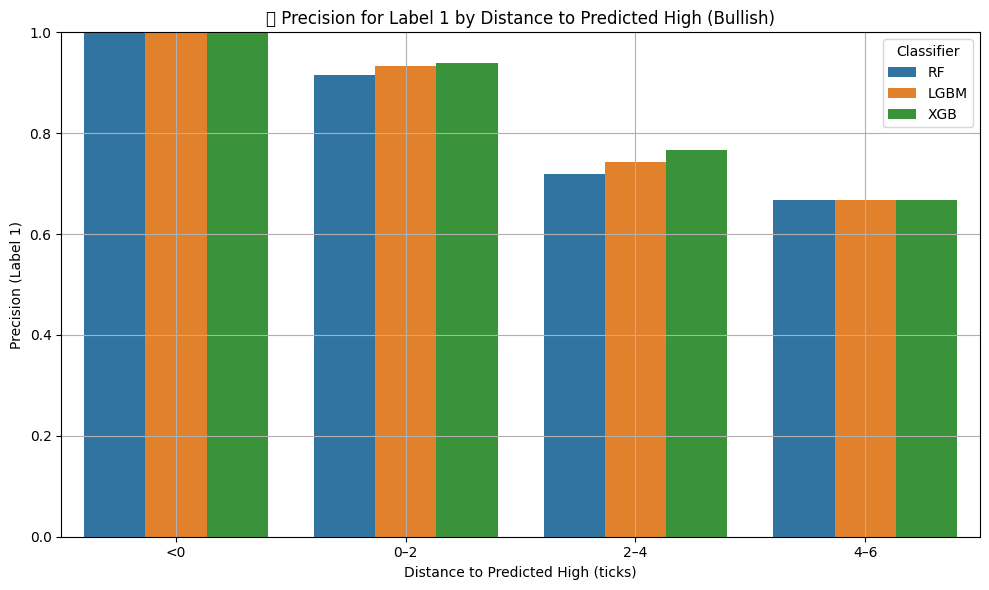

,Bin,Model,Precision_1,Count
0,<0,RF,1.000000,3
1,0–2,RF,0.916201,348
2,2–4,RF,0.718750,49
3,4–6,RF,0.666667,5
4,<0,LGBM,1.000000,3
5,0–2,LGBM,0.933702,348
6,2–4,LGBM,0.741935,49
7,4–6,LGBM,0.666667,5
8,<0,XGB,1.000000,3
9,0–2,XGB,0.939227,348


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

# Use Bullish variant as example – you can repeat for All variant similarly
df_test_bullish = X_test_bullish.copy()
df_test_bullish["Close"] = trainer.x_test_with_meta.loc[X_test_bullish.index]["Close"]
df_test_bullish["Predicted_High"] = trainer.x_test_with_meta.loc[X_test_bullish.index]["Predicted_High"]
df_test_bullish["distance"] = df_test_bullish["Predicted_High"] - df_test_bullish["Close"]

# Add classifier predictions for comparison (assumes you've trained already)
df_test_bullish["True_Label"] = y_test_bullish.values
df_test_bullish["Pred_RF"] = classifier_trainer_bullish.rf_results["predictions"]
df_test_bullish["Pred_LGBM"] = classifier_trainer_bullish.lgbm_results["predictions"]
df_test_bullish["Pred_XGB"] = classifier_trainer_bullish.xgb_results["predictions"]

# Define distance bins (in ticks or points)
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_test_bullish["distance_bin"] = pd.cut(df_test_bullish["distance"], bins=bins, labels=labels)

# Calculate precision per bin per classifier (for Label 1)
results = []
for model in ["Pred_RF", "Pred_LGBM", "Pred_XGB"]:
    for bin_label in labels:
        bin_data = df_test_bullish[df_test_bullish["distance_bin"] == bin_label]
        if not bin_data.empty:
            y_true = bin_data["True_Label"]
            y_pred = bin_data[model]
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            results.append({
                "Bin": bin_label,
                "Model": model.replace("Pred_", ""),
                "Precision_1": prec,
                "Count": len(bin_data)
            })

df_precision_by_distance = pd.DataFrame(results)

# 📊 Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_precision_by_distance, x="Bin", y="Precision_1", hue="Model")
plt.title("📈 Precision for Label 1 by Distance to Predicted High (Bullish)")
plt.ylabel("Precision (Label 1)")
plt.xlabel("Distance to Predicted High (ticks)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

# Optional: Display table
df_precision_by_distance

In [26]:
# Step 1: Start from df_labeled_bullish and add Prev_Label
df_labeled_bullish_with_prev_label = df_labeled_bullish.copy()
df_labeled_bullish_with_prev_label["Prev_Label"] = df_labeled_bullish_with_prev_label["long_good_bar_label"].shift(1)

# Step 2: Drop rows where Prev_Label is NaN (first row after shift)
df_labeled_bullish_with_prev_label = df_labeled_bullish_with_prev_label.dropna(subset=["Prev_Label"])

# Step 3: Make sure Prev_Label is int
df_labeled_bullish_with_prev_label["Prev_Label"] = df_labeled_bullish_with_prev_label["Prev_Label"].astype(int)

# ✅ Now you're ready to run the CV distance analysis cell!


🎯 Cross-Validated Precision by Distance Bin Analysis

📊 Distance Bin Distribution:
  <0: 3 samples (0.1%)
  0–2: 1370 samples (67.7%)
  2–4: 477 samples (23.6%)
  4–6: 132 samples (6.5%)
  6–8: 33 samples (1.6%)
  8+: 8 samples (0.4%)

🔁 Running cross-validation by distance bin...
  ⚠️ Skipping bin <0 - insufficient samples (3)
  Processing bin 0–2 (1370 samples)
    RF - Precision: 0.876 (from 1370 cross-validated samples)
    LGBM - Precision: 0.892 (from 1370 cross-validated samples)
    XGB - Precision: 0.887 (from 1370 cross-validated samples)
  Processing bin 2–4 (477 samples)
    RF - Precision: 0.863 (from 477 cross-validated samples)
    LGBM - Precision: 0.875 (from 477 cross-validated samples)
    XGB - Precision: 0.862 (from 477 cross-validated samples)
  Processing bin 4–6 (132 samples)
    RF - Precision: 0.833 (from 132 cross-validated samples)
    LGBM - Precision: 0.812 (from 132 cross-validated samples)
    XGB - Precision: 0.816 (from 132 cross-validated samples)
  P

C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\118364399.py:138: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


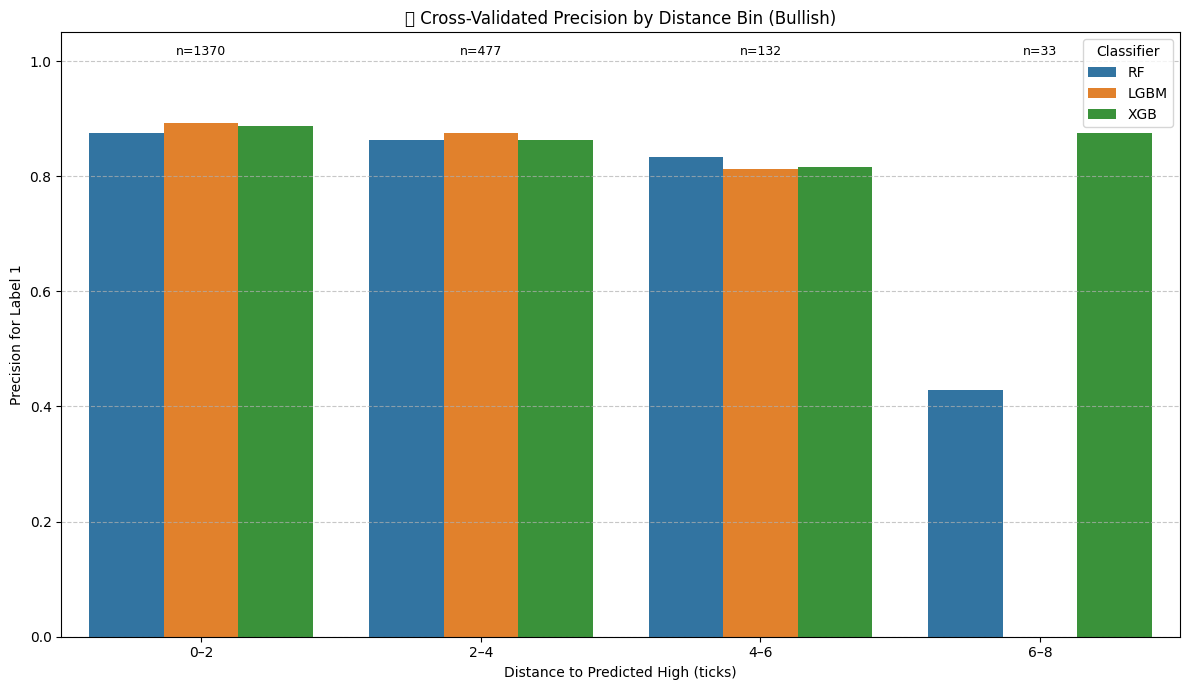


📋 Cross-Validated Precision (Label 1) by Distance Bin:


Model,LGBM,RF,XGB,Sample_Count
Bin,,,,
0–2,0.892,0.876,0.887,1370
2–4,0.875,0.863,0.862,477
4–6,0.812,0.833,0.816,132
6–8,0.000,0.429,0.875,33


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score
from sklearn.model_selection import KFold

# Use Bullish variant as example
print("🎯 Cross-Validated Precision by Distance Bin Analysis\n")

# Combine train and test data for cross-validation
X_bullish_all = pd.concat([X_train_bullish, X_test_bullish])
y_bullish_all = pd.concat([y_train_bullish, y_test_bullish])

# Get Close and Predicted_High for all samples
all_indices = X_bullish_all.index
filtered_meta = trainer.x_test_with_meta.loc[trainer.x_test_with_meta.index.isin(all_indices)]

# Get only needed columns from meta and rename them to avoid overlap
filtered_meta_subset = filtered_meta[["Close", "Predicted_High"]].copy()
filtered_meta_subset = filtered_meta_subset.rename(columns={
    "Close": "Price_Close", 
    "Predicted_High": "Price_Predicted_High"
})

# Create the main dataframe with features and labels
df_bullish_cv = X_bullish_all.copy()
df_bullish_cv["True_Label"] = y_bullish_all.values

# Add price data with renamed columns to avoid overlap
df_bullish_cv = df_bullish_cv.join(filtered_meta_subset, how="inner")

# Calculate distance using renamed columns
df_bullish_cv["distance"] = df_bullish_cv["Price_Predicted_High"] - df_bullish_cv["Price_Close"]

# Define distance bins (in ticks or points)
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_bullish_cv["distance_bin"] = pd.cut(df_bullish_cv["distance"], bins=bins, labels=labels)

# Print bin distribution
bin_counts = df_bullish_cv["distance_bin"].value_counts().sort_index()
print("📊 Distance Bin Distribution:")
for bin_label, count in bin_counts.items():
    percent = count / len(df_bullish_cv) * 100
    print(f"  {bin_label}: {count} samples ({percent:.1f}%)")

# Create K-fold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize models
models = {
    "RF": RandomForestClassifier(random_state=42),
    "LGBM": LGBMClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Store results by bin and model
cv_precision_by_bin = []

print("\n🔁 Running cross-validation by distance bin...")

# Process each bin separately
for bin_label in labels:
    # Get samples in this bin
    bin_mask = df_bullish_cv["distance_bin"] == bin_label
    bin_samples = df_bullish_cv[bin_mask]
    
    if len(bin_samples) < 10:  # Skip bins with too few samples
        print(f"  ⚠️ Skipping bin {bin_label} - insufficient samples ({len(bin_samples)})")
        continue
        
    print(f"  Processing bin {bin_label} ({len(bin_samples)} samples)")
    
    # Get features and labels - exclude all non-feature columns
    cols_to_drop = ["True_Label", "distance", "distance_bin", "Price_Close", "Price_Predicted_High"]
    X_bin = bin_samples.drop(cols_to_drop, axis=1, errors='ignore')
    y_bin = bin_samples["True_Label"]
    
    # Apply cross-validation for each model
    for model_name, model in models.items():
        # Store predictions from each fold
        all_true = []
        all_pred = []
        
        for train_idx, test_idx in kf.split(X_bin):
            # Skip if a fold has too few samples of each class
            if len(np.unique(y_bin.iloc[train_idx])) < 2 or len(np.unique(y_bin.iloc[test_idx])) < 2:
                continue
                
            # Split data into train and test for this fold
            X_train_fold, X_test_fold = X_bin.iloc[train_idx], X_bin.iloc[test_idx]
            y_train_fold, y_test_fold = y_bin.iloc[train_idx], y_bin.iloc[test_idx]
            
            # Train and predict
            model.fit(X_train_fold, y_train_fold)
            y_pred_fold = model.predict(X_test_fold)
            
            # Store results
            all_true.extend(y_test_fold)
            all_pred.extend(y_pred_fold)
        
        # Calculate precision only if we have predictions
        if len(all_true) > 0 and 1 in all_true:
            prec = precision_score(all_true, all_pred, pos_label=1, zero_division=0)
            
            # Add to results
            cv_precision_by_bin.append({
                "Bin": bin_label,
                "Model": model_name,
                "Precision_1": prec,
                "Count": len(bin_samples)
            })
            print(f"    {model_name} - Precision: {prec:.3f} (from {len(all_true)} cross-validated samples)")

# Convert to DataFrame
df_cv_precision_by_distance = pd.DataFrame(cv_precision_by_bin)

# Plot results if we have data
if not df_cv_precision_by_distance.empty:
    plt.figure(figsize=(12, 7))
    
    # Main bar chart
    ax = sns.barplot(data=df_cv_precision_by_distance, x="Bin", y="Precision_1", hue="Model")
    
    # Add count labels above bars
    for bin_label in df_cv_precision_by_distance["Bin"].unique():
        bin_count = df_cv_precision_by_distance[df_cv_precision_by_distance["Bin"] == bin_label]["Count"].iloc[0]
        bin_index = list(df_cv_precision_by_distance["Bin"].unique()).index(bin_label)
        plt.text(bin_index, 1.01, f"n={bin_count}", ha='center', fontsize=9)
    
    plt.title("📊 Cross-Validated Precision by Distance Bin (Bullish)")
    plt.ylabel("Precision for Label 1")
    plt.xlabel("Distance to Predicted High (ticks)")
    plt.ylim(0, 1.05)  # Leave room for count labels
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Classifier")
    plt.tight_layout()
    plt.show()

# Display table with results
if not df_cv_precision_by_distance.empty:
    # Create a pivot table for easier reading
    pivot_df = df_cv_precision_by_distance.pivot(index="Bin", columns="Model", values="Precision_1")
    pivot_df["Sample_Count"] = df_cv_precision_by_distance.drop_duplicates("Bin").set_index("Bin")["Count"]
    
    # Sort by bin
    bin_order = {label: i for i, label in enumerate(labels)}
    pivot_df = pivot_df.reset_index()
    pivot_df["bin_order"] = pivot_df["Bin"].map(bin_order)
    pivot_df = pivot_df.sort_values("bin_order").drop("bin_order", axis=1).set_index("Bin")
    
    print("\n📋 Cross-Validated Precision (Label 1) by Distance Bin:")
    display(pivot_df.style.format("{:.3f}", subset=["RF", "LGBM", "XGB"]))
else:
    print("\n⚠️ No results to display - check if bins have sufficient samples")

# creating new labels option B 


In [28]:
df_for_labeling = trainer.x_test_with_meta.copy()
df_for_labeling["Predicted_High"] = trainer.predictions[:len(df_for_labeling)]

# ❌ No shifting
# ✅ Use current Close + current Predicted_High to label this bar
df_labeled_bullish = label_generator.long_good_bar_label_bullish_only_goal_b(df_for_labeling)

df_labeled_all = label_generator.long_good_bar_label_all_goal_b(df_for_labeling)



✅ Goal B Bullish Label applied (1 = this bar's High ≥ this bar's Predicted_High).
✅ Goal B ALL Label applied (1 = High ≥ Predicted_High).


In [28]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_b = trainer.copy()  # ✅ Create a separate copy for Option B

# 🔵 All-bar version (Goal B)
X_train_all_goal_b, y_train_all_goal_b, X_test_all_goal_b, y_test_all_goal_b = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)
smote_all_goal_b = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_b, classifier_y_train_bal_all_goal_b = smote_all_goal_b.fit_resample(
    X_train_all_goal_b, y_train_all_goal_b
)

trainer_b.x_test_with_meta = df_labeled_all.loc[X_test_all_goal_b.index]

print("🧪 Notebook Alignment Check – Option B")
print("trainer_b.x_test_with_meta index:", trainer_b.x_test_with_meta.index[:5])
print("X_test_all_goal_b index:", X_test_all_goal_b.index[:5])
print("⏳ Are they equal?", trainer_b.x_test_with_meta.index.equals(X_test_all_goal_b.index))

# ✅ Train classifiers (All Bars)
classifier_trainer_all_goal_b = ClassifierModelTrainer()
classifier_trainer_all_goal_b.train_all_classifiers(
    classifier_X_train_bal_all_goal_b,
    classifier_y_train_bal_all_goal_b,
    X_test_all_goal_b,
    y_test_all_goal_b,
    trainer_b
)

# 🟣 Bullish-only version (Goal B)
X_train_bullish_goal_b, y_train_bullish_goal_b, X_test_bullish_goal_b, y_test_bullish_goal_b = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

X_test_all_goal_b = X_test_all_goal_b.select_dtypes(include='number')

smote_bullish_goal_b = SMOTE(random_state=42)
classifier_X_train_bal_bullish_goal_b, classifier_y_train_bal_bullish_goal_b = smote_bullish_goal_b.fit_resample(
    X_train_bullish_goal_b, y_train_bullish_goal_b
)

trainer_b.x_test_with_meta = df_labeled_bullish.loc[X_test_bullish_goal_b.index]
X_test_bullish_goal_b = X_test_bullish_goal_b.select_dtypes(include='number')

classifier_trainer_bullish_goal_b = ClassifierModelTrainer()
classifier_trainer_bullish_goal_b.train_all_classifiers(
    classifier_X_train_bal_bullish_goal_b,
    classifier_y_train_bal_bullish_goal_b,
    X_test_bullish_goal_b,
    y_test_bullish_goal_b,
    trainer_b
)

print("✅ Training complete using Goal B labels (All Bars + Bullish Only)")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-21 07:35:00
1                       1       2025-01-21 07:40:00
2                       1       2025-01-21 07:45:00
3                       0       2025-01-21 07:50:00
4                       0       2025-01-21 07:55:00
🧪 Notebook Alignment Check – Option B
trainer_b.x_test_with_meta index: DatetimeIndex(['2025-01-21 07:35:00', '2025-01-21 07:40:00',
               '2025-01-21 07:45:00', '2025-01-21 07:50:00',
               '2025-01-21 07:55:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
X_test_all_goal_b index: DatetimeIndex(['2025-01-21 07:35:00', '2025-01-21 07:40:00',
               '2025-01-21 07:45:00', '2025-01-21 07:50:00',
               '2025-01-21 07:55:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
⏳ Are they equal? True
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training

In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# ✅ Define Goal B variants
variants_b = {
    "GoalB_All": (X_train_all_goal_b, y_train_all_goal_b, X_test_all_goal_b, y_test_all_goal_b),
    "GoalB_Bullish": (X_train_bullish_goal_b, y_train_bullish_goal_b, X_test_bullish_goal_b, y_test_bullish_goal_b),
}

# Models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results_b_smote = []
print("📊 Cross-Validation Results – Goal B with SMOTE (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants_b.items():
    print(f"🔹 {variant_name}:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_cls in model_classes.items():
        y_true_all = []
        y_pred_all = []

        for train_idx, test_idx in skf.split(X_all, y_all):
            X_fold_train, y_fold_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_fold_test, y_fold_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

            # 🟦 Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

            model = model_cls(random_state=42)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_fold_test)

            y_true_all.extend(y_fold_test)
            y_pred_all.extend(y_pred)

        report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results_b_smote.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Optional: convert to DataFrame
cv_results_b_smote_df = pd.DataFrame(cv_results_b_smote)


📊 Cross-Validation Results – Goal B with SMOTE (F1 + Precision for Label 1 and 0):

🔹 GoalB_All:

  RandomForest: F1 = 0.842 | Precision (1) = 0.853 | Precision (0) = 0.846
  LightGBM: F1 = 0.865 | Precision (1) = 0.846 | Precision (0) = 0.887
  XGBoost: F1 = 0.870 | Precision (1) = 0.855 | Precision (0) = 0.889
------------------------------------------------------------
🔹 GoalB_Bullish:

  RandomForest: F1 = 0.841 | Precision (1) = 0.856 | Precision (0) = 0.842
  LightGBM: F1 = 0.877 | Precision (1) = 0.861 | Precision (0) = 0.897
  XGBoost: F1 = 0.872 | Precision (1) = 0.865 | Precision (0) = 0.886
------------------------------------------------------------


# creating new labels option C
### ✅ Decision: Moving Forward with **Option C** for Classifier Labeling

After testing and evaluating multiple labeling strategies, we have decided to adopt **Option C** as our main classifier labeling method.

---

### 🔍 What is Option C?

Option C labels bar **T** as a _good bar_ if the **next bar's High** (T+1) is greater than or equal to the **Predicted High** generated at T.

This means:
> **"Given the prediction I made at time T, was it realistic in hindsight — and can I learn from the setup at T to improve future trades?"**

---

### ❌ Why we **discarded Option A**

- **Option A** labeled each bar by checking if the **current bar's High** (T) reached the **previous prediction** (from T-1).
- This setup creates artificially high precision/recall, since it reflects what has already happened — not what can be predicted.
- It’s **not usable for real-time trading**, because the label depends on known outcomes that the model doesn't have at decision time.

---

### ✅ Why Option C is better for live trading

- It **simulates a real decision-making setup**: I’m at bar T and want to know whether to trade, based on whether bar T+1 will reach my predicted target.
- It allows the classifier to learn patterns that **precede successful outcomes**, without leaking future data.
- Performance is more realistic and **aligned with live trading conditions**, even if precision/recall is lower.

---

### 🧭 Next Steps

- Focus on **improving Option C metrics** with better features, label refinements, or model tuning.
- Evaluate **bullish-only vs. all-bar variants** depending on trade filtering goals.
- Treat Option A as a possible **feature analysis tool**, but not for live decisions.



In [34]:
# ✅ Option C: Labeling using Next Bar's High vs Current Predicted High
df_for_labeling_c = trainer.x_test_with_meta.copy()
df_for_labeling_c["Predicted_High"] = trainer.predictions[:len(df_for_labeling_c)]

# ✅ Apply Option C labels
df_labeled_all_c = label_generator.long_good_bar_label_all_goal_c(df_for_labeling_c)
df_labeled_bullish_c = label_generator.long_good_bar_label_bullish_only_goal_c(df_for_labeling_c)


✅ Goal C ALL Label applied (1 = Next High ≥ Predicted High).
✅ Goal C Bullish Label applied (1 = bullish setup + Next High ≥ Predicted High).


In [35]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_c = trainer.copy()  # ✅ Create a dedicated copy for Option C

# 🔵 All-bar version (Goal C)
X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

# ✅ Balance the training set
smote_all_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_c, classifier_y_train_bal_all_goal_c = smote_all_goal_c.fit_resample(
    X_train_all_goal_c, y_train_all_goal_c
)

# ✅ Store metadata for alignment
trainer_c.x_test_with_meta = df_labeled_all_c.loc[X_test_all_goal_c.index]

# ✅ Keep only numeric columns
X_test_all_goal_c = X_test_all_goal_c.select_dtypes(include='number')

print("🧪 Notebook Alignment Check – Option C")
print("trainer_c.x_test_with_meta index:", trainer_c.x_test_with_meta.index[:5])
print("X_test_all_goal_c index:", X_test_all_goal_c.index[:5])
print("⏳ Are they equal?", trainer_c.x_test_with_meta.index.equals(X_test_all_goal_c.index))

# ✅ Train classifiers (All Bars)
classifier_trainer_all_goal_c = ClassifierModelTrainer()
classifier_trainer_all_goal_c.train_all_classifiers(
    classifier_X_train_bal_all_goal_c,
    classifier_y_train_bal_all_goal_c,
    X_test_all_goal_c,
    y_test_all_goal_c,
    trainer_c
)

# 🟣 Bullish-only version (Goal C)
X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_bullish_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_bullish_goal_c, classifier_y_train_bal_bullish_goal_c = smote_bullish_goal_c.fit_resample(
    X_train_bullish_goal_c, y_train_bullish_goal_c
)

trainer_c.x_test_with_meta = df_labeled_bullish_c.loc[X_test_bullish_goal_c.index]

X_test_bullish_goal_c = X_test_bullish_goal_c.select_dtypes(include='number')

classifier_trainer_bullish_goal_c = ClassifierModelTrainer()
classifier_trainer_bullish_goal_c.train_all_classifiers(
    classifier_X_train_bal_bullish_goal_c,
    classifier_y_train_bal_bullish_goal_c,
    X_test_bullish_goal_c,
    y_test_bullish_goal_c,
    trainer_c
)

print("✅ Training complete using Goal C labels (All Bars + Bullish Only)")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-21 07:35:00
1                       1       2025-01-21 07:40:00
2                       0       2025-01-21 07:45:00
3                       0       2025-01-21 07:50:00
4                       0       2025-01-21 07:55:00
🧪 Notebook Alignment Check – Option C
trainer_c.x_test_with_meta index: DatetimeIndex(['2025-01-21 07:35:00', '2025-01-21 07:40:00',
               '2025-01-21 07:45:00', '2025-01-21 07:50:00',
               '2025-01-21 07:55:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
X_test_all_goal_c index: DatetimeIndex(['2025-01-21 07:35:00', '2025-01-21 07:40:00',
               '2025-01-21 07:45:00', '2025-01-21 07:50:00',
               '2025-01-21 07:55:00'],
              dtype='datetime64[ns]', name='Timestamp', freq=None)
⏳ Are they equal? True
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# ✅ Define Goal B variants
variants_c = {
    "GoalB_All": (X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c),
    "GoalB_Bullish": (X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c),
}

# Models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results_c_smote = []
print("📊 Cross-Validation Results – Goal c with SMOTE (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants_c.items():
    print(f"🔹 {variant_name}:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_cls in model_classes.items():
        y_true_all = []
        y_pred_all = []

        for train_idx, test_idx in skf.split(X_all, y_all):
            X_fold_train, y_fold_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_fold_test, y_fold_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

            # 🟦 Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

            model = model_cls(random_state=42)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_fold_test)

            y_true_all.extend(y_fold_test)
            y_pred_all.extend(y_pred)

        report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results_c_smote.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Optional: convert to DataFrame
cv_results_c_smote_df = pd.DataFrame(cv_results_c_smote)


📊 Cross-Validation Results – Goal c with SMOTE (F1 + Precision for Label 1 and 0):

🔹 GoalB_All:

  RandomForest: F1 = 0.508 | Precision (1) = 0.510 | Precision (0) = 0.539
  LightGBM: F1 = 0.563 | Precision (1) = 0.555 | Precision (0) = 0.586
  XGBoost: F1 = 0.551 | Precision (1) = 0.543 | Precision (0) = 0.574
------------------------------------------------------------
🔹 GoalB_Bullish:

  RandomForest: F1 = 0.526 | Precision (1) = 0.541 | Precision (0) = 0.564
  LightGBM: F1 = 0.539 | Precision (1) = 0.555 | Precision (0) = 0.576
  XGBoost: F1 = 0.552 | Precision (1) = 0.557 | Precision (0) = 0.582
------------------------------------------------------------


In [36]:
# ✅ Add previous signal features to labeled DataFrames (Option C)

label_col = "long_good_bar_label"  # still the same for Option C

# --- For ALL (Goal C) ---
df_labeled_all_c["Prev_Label"] = df_labeled_all_c[label_col].shift(1)

# --- For BULLISH (Goal C) ---
df_labeled_bullish_c["Prev_Label"] = df_labeled_bullish_c[label_col].shift(1)

# Drop rows with NaN in Prev_Label after shift
df_labeled_all_c = df_labeled_all_c.dropna(subset=["Prev_Label"])
df_labeled_bullish_c = df_labeled_bullish_c.dropna(subset=["Prev_Label"])

# Convert Prev_Label to integer
df_labeled_all_c["Prev_Label"] = df_labeled_all_c["Prev_Label"].astype(int)
df_labeled_bullish_c["Prev_Label"] = df_labeled_bullish_c["Prev_Label"].astype(int)

print("✅ Previous signal features added to both Option C labeled DataFrames.")


✅ Previous signal features added to both Option C labeled DataFrames.


In [37]:
from imblearn.over_sampling import SMOTE

processor = DataProcessor()
trainer_c2 = trainer.copy()  # ✅ Separate copy for this training round (Option C with updated labels)

# 🔵 All-bar version (Goal C)
X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_all_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_all_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_all_goal_c, classifier_y_train_bal_all_goal_c = smote_all_goal_c.fit_resample(
    X_train_all_goal_c, y_train_all_goal_c
)

trainer_c2.x_test_with_meta = df_labeled_all_c.loc[X_test_all_goal_c.index]
X_test_all_goal_c = X_test_all_goal_c.select_dtypes(include='number')

classifier_trainer_all_goal_c = ClassifierModelTrainer()
classifier_trainer_all_goal_c.train_all_classifiers(
    classifier_X_train_bal_all_goal_c,
    classifier_y_train_bal_all_goal_c,
    X_test_all_goal_c,
    y_test_all_goal_c,
    trainer_c2
)

# 🟣 Bullish-only version (Goal C)
X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c = processor.prepare_dataset_for_regression_sequential(
    data=df_labeled_bullish_c,
    target_column="long_good_bar_label",
    drop_target=True,
    split_ratio=0.8
)

smote_bullish_goal_c = SMOTE(random_state=42)
classifier_X_train_bal_bullish_goal_c, classifier_y_train_bal_bullish_goal_c = smote_bullish_goal_c.fit_resample(
    X_train_bullish_goal_c, y_train_bullish_goal_c
)

trainer_c2.x_test_with_meta = df_labeled_bullish_c.loc[X_test_bullish_goal_c.index]
X_test_bullish_goal_c = X_test_bullish_goal_c.select_dtypes(include='number')

classifier_trainer_bullish_goal_c = ClassifierModelTrainer()
classifier_trainer_bullish_goal_c.train_all_classifiers(
    classifier_X_train_bal_bullish_goal_c,
    classifier_y_train_bal_bullish_goal_c,
    X_test_bullish_goal_c,
    y_test_bullish_goal_c,
    trainer_c2
)

print("✅ Training complete using Option C (fresh-labeled) DataFrames")



✅ Sample Data Alignment Check:
   Sample Target (y_test) Corresponding Feature Row
0                       1       2025-01-21 07:35:00
1                       1       2025-01-21 07:40:00
2                       0       2025-01-21 07:45:00
3                       0       2025-01-21 07:50:00
4                       0       2025-01-21 07:55:00
✅ ClassifierModelTrainer initialized!

🚀 Training all classifiers...

🚀 Training RandomForest...

📊 RandomForest Evaluation:
              precision    recall  f1-score   support

           0       0.44      0.80      0.57       178
           1       0.58      0.21      0.31       228

    accuracy                           0.47       406
   macro avg       0.51      0.51      0.44       406
weighted avg       0.52      0.47      0.43       406


🎯 RandomForest Accuracy: 0.4729

🚀 Training LightGBM...

📊 LightGBM Evaluation:
              precision    recall  f1-score   support

           0       0.47      0.64      0.55       178
           1  

In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# ✅ Define Goal B variants
variants_c = {
    "GoalB_All": (X_train_all_goal_c, y_train_all_goal_c, X_test_all_goal_c, y_test_all_goal_c),
    "GoalB_Bullish": (X_train_bullish_goal_c, y_train_bullish_goal_c, X_test_bullish_goal_c, y_test_bullish_goal_c),
}

# Models
model_classes = {
    'RandomForest': RandomForestClassifier,
    'LightGBM': LGBMClassifier,
    'XGBoost': XGBClassifier,
}

cv_results_c_smote = []
print("📊 Cross-Validation Results – Goal C with SMOTE (F1 + Precision for Label 1 and 0):\n")

for variant_name, (X_train, y_train, X_test, y_test) in variants_c.items():
    print(f"🔹 {variant_name}:\n")
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model_cls in model_classes.items():
        y_true_all = []
        y_pred_all = []

        for train_idx, test_idx in skf.split(X_all, y_all):
            X_fold_train, y_fold_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_fold_test, y_fold_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

            # 🟦 Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

            model = model_cls(random_state=42)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_fold_test)

            y_true_all.extend(y_fold_test)
            y_pred_all.extend(y_pred)

        report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)

        f1_label_1 = report['1']['f1-score']
        precision_1 = report['1']['precision']
        precision_0 = report['0']['precision']

        print(f"  {model_name}: F1 = {f1_label_1:.3f} | Precision (1) = {precision_1:.3f} | Precision (0) = {precision_0:.3f}")
        cv_results_c_smote.append({
            "Variant": variant_name,
            "Model": model_name,
            "F1_Label_1": f1_label_1,
            "Precision_Label_1": precision_1,
            "Precision_Label_0": precision_0
        })

    print("-" * 60)

# Optional: convert to DataFrame
cv_results_c_smote_df = pd.DataFrame(cv_results_c_smote)


📊 Cross-Validation Results – Goal C with SMOTE (F1 + Precision for Label 1 and 0):

🔹 GoalB_All:

  RandomForest: F1 = 0.508 | Precision (1) = 0.510 | Precision (0) = 0.539
  LightGBM: F1 = 0.563 | Precision (1) = 0.555 | Precision (0) = 0.586
  XGBoost: F1 = 0.551 | Precision (1) = 0.543 | Precision (0) = 0.574
------------------------------------------------------------
🔹 GoalB_Bullish:

  RandomForest: F1 = 0.526 | Precision (1) = 0.541 | Precision (0) = 0.564
  LightGBM: F1 = 0.539 | Precision (1) = 0.555 | Precision (0) = 0.576
  XGBoost: F1 = 0.552 | Precision (1) = 0.557 | Precision (0) = 0.582
------------------------------------------------------------


# option c distibutn of precision in Bins


🔍 Missing timestamps in trainer_c.x_test_with_meta: 4
🧯 First few missing timestamps: [Timestamp('2025-01-22 07:00:00'), Timestamp('2025-01-22 07:05:00'), Timestamp('2025-01-22 07:45:00'), Timestamp('2025-01-22 13:30:00')]


C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\1978756145.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


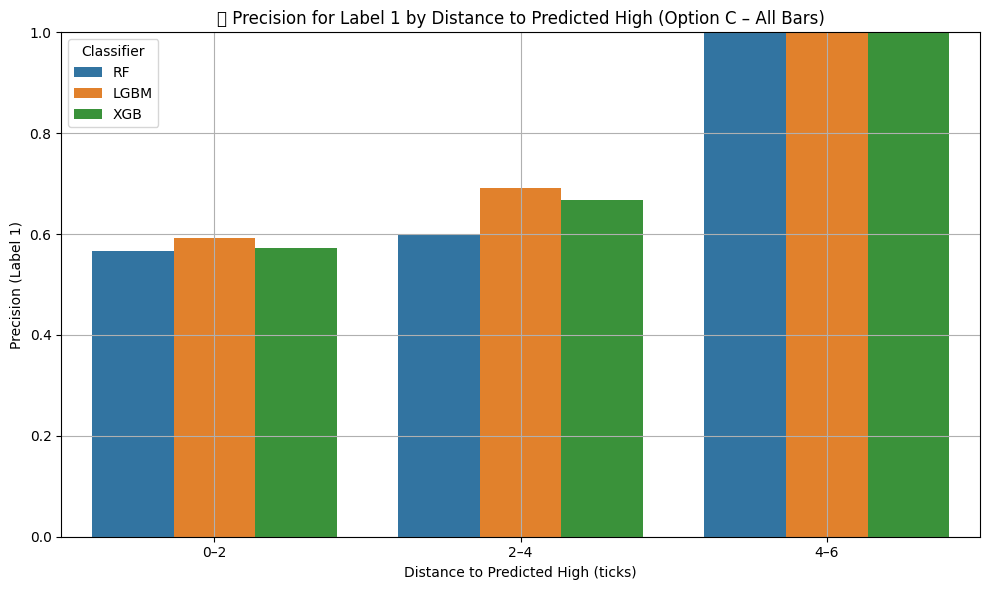

,Bin,Model,Precision_1,Count
0,0–2,RF,0.567164,348
1,2–4,RF,0.600000,49
2,4–6,RF,1.000000,5
3,0–2,LGBM,0.592593,348
4,2–4,LGBM,0.692308,49
5,4–6,LGBM,1.000000,5
6,0–2,XGB,0.572414,348
7,2–4,XGB,0.666667,49
8,4–6,XGB,1.000000,5


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

# ✅ DEBUG: Check for index mismatch
missing_idx = [i for i in X_test_all_goal_c.index if i not in trainer_c.x_test_with_meta.index]
print(f"🔍 Missing timestamps in trainer_c.x_test_with_meta: {len(missing_idx)}")
if missing_idx:
    print("🧯 First few missing timestamps:", missing_idx[:5])

# ✅ Fix: Align trainer_c.x_test_with_meta to valid test indices
trainer_c.x_test_with_meta = trainer_c.x_test_with_meta.loc[
    trainer_c.x_test_with_meta.index.intersection(X_test_all_goal_c.index)
]

# ✅ Use All Bars variant from Option C
df_test_all_c = X_test_all_goal_c.copy()
df_test_all_c["Close"] = trainer_c.x_test_with_meta["Close"]
df_test_all_c["Predicted_High"] = trainer_c.x_test_with_meta["Predicted_High"]
df_test_all_c["distance"] = df_test_all_c["Predicted_High"] - df_test_all_c["Close"]

# ✅ Add true labels and predictions
df_test_all_c["True_Label"] = y_test_all_goal_c.values
df_test_all_c["Pred_RF"] = classifier_trainer_all_goal_c.rf_results["predictions"]
df_test_all_c["Pred_LGBM"] = classifier_trainer_all_goal_c.lgbm_results["predictions"]
df_test_all_c["Pred_XGB"] = classifier_trainer_all_goal_c.xgb_results["predictions"]

# ✅ Define distance bins
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_test_all_c["distance_bin"] = pd.cut(df_test_all_c["distance"], bins=bins, labels=labels)

# ✅ Calculate precision per bin per classifier
results = []
for model in ["Pred_RF", "Pred_LGBM", "Pred_XGB"]:
    for bin_label in labels:
        bin_data = df_test_all_c[df_test_all_c["distance_bin"] == bin_label]
        if not bin_data.empty:
            y_true = bin_data["True_Label"]
            y_pred = bin_data[model]
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            results.append({
                "Bin": bin_label,
                "Model": model.replace("Pred_", ""),
                "Precision_1": prec,
                "Count": len(bin_data)
            })

df_precision_by_distance_all_c = pd.DataFrame(results)

# ✅ Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_precision_by_distance_all_c, x="Bin", y="Precision_1", hue="Model")
plt.title("📈 Precision for Label 1 by Distance to Predicted High (Option C – All Bars)")
plt.ylabel("Precision (Label 1)")
plt.xlabel("Distance to Predicted High (ticks)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

# ✅ Optional: View results table
df_precision_by_distance_all_c


## Bullish only

C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\2891530321.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


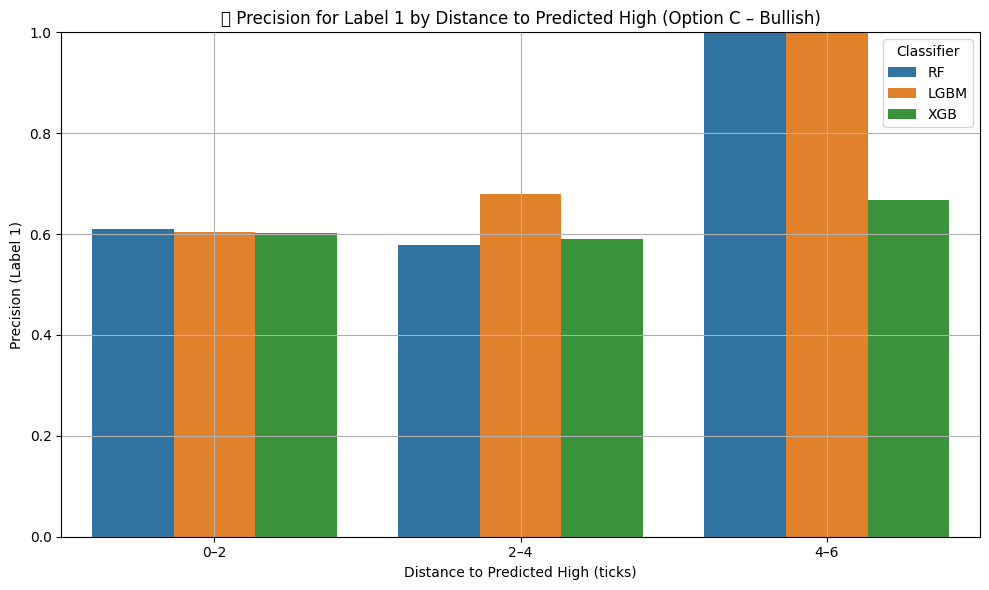

,Bin,Model,Precision_1,Count
0,0–2,RF,0.609524,351
1,2–4,RF,0.578947,49
2,4–6,RF,1.000000,5
3,0–2,LGBM,0.604938,351
4,2–4,LGBM,0.678571,49
5,4–6,LGBM,1.000000,5
6,0–2,XGB,0.601852,351
7,2–4,XGB,0.590909,49
8,4–6,XGB,0.666667,5


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score

# ✅ Use Bullish variant from Option C
df_test_bullish_c = X_test_bullish_goal_c.copy()
df_test_bullish_c["Close"] = trainer_c.x_test_with_meta.loc[X_test_bullish_goal_c.index]["Close"]
df_test_bullish_c["Predicted_High"] = trainer_c.x_test_with_meta.loc[X_test_bullish_goal_c.index]["Predicted_High"]
df_test_bullish_c["distance"] = df_test_bullish_c["Predicted_High"] - df_test_bullish_c["Close"]

# ✅ Add true labels and predictions
df_test_bullish_c["True_Label"] = y_test_bullish_goal_c.values
df_test_bullish_c["Pred_RF"] = classifier_trainer_bullish_goal_c.rf_results["predictions"]
df_test_bullish_c["Pred_LGBM"] = classifier_trainer_bullish_goal_c.lgbm_results["predictions"]
df_test_bullish_c["Pred_XGB"] = classifier_trainer_bullish_goal_c.xgb_results["predictions"]

# ✅ Define distance bins
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_test_bullish_c["distance_bin"] = pd.cut(df_test_bullish_c["distance"], bins=bins, labels=labels)

# ✅ Calculate precision per bin per classifier
results = []
for model in ["Pred_RF", "Pred_LGBM", "Pred_XGB"]:
    for bin_label in labels:
        bin_data = df_test_bullish_c[df_test_bullish_c["distance_bin"] == bin_label]
        if not bin_data.empty:
            y_true = bin_data["True_Label"]
            y_pred = bin_data[model]
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            results.append({
                "Bin": bin_label,
                "Model": model.replace("Pred_", ""),
                "Precision_1": prec,
                "Count": len(bin_data)
            })

df_precision_by_distance_c = pd.DataFrame(results)

# ✅ Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_precision_by_distance_c, x="Bin", y="Precision_1", hue="Model")
plt.title("📈 Precision for Label 1 by Distance to Predicted High (Option C – Bullish)")
plt.ylabel("Precision (Label 1)")
plt.xlabel("Distance to Predicted High (ticks)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

# ✅ Optional: view table
df_precision_by_distance_c


🎯 Cross-Validated Precision by Distance Bin Analysis – Option C (Bullish)

📊 Distance Bin Distribution:
  <0: 0 samples (0.0%)
  0–2: 351 samples (86.7%)
  2–4: 49 samples (12.1%)
  4–6: 5 samples (1.2%)
  6–8: 0 samples (0.0%)
  8+: 0 samples (0.0%)

🔁 Running cross-validation by distance bin...
  ⚠️ Skipping bin <0 - insufficient samples (0)
  Processing bin 0–2 (351 samples)
    RF - Precision: 0.534 (from 351 cross-validated samples)
    LGBM - Precision: 0.556 (from 351 cross-validated samples)
    XGB - Precision: 0.557 (from 351 cross-validated samples)
  Processing bin 2–4 (49 samples)
    RF - Precision: 0.714 (from 49 cross-validated samples)
    LGBM - Precision: 0.596 (from 49 cross-validated samples)
    XGB - Precision: 0.700 (from 49 cross-validated samples)
  ⚠️ Skipping bin 4–6 - insufficient samples (5)
  ⚠️ Skipping bin 6–8 - insufficient samples (0)
  ⚠️ Skipping bin 8+ - insufficient samples (0)


C:\Users\itzha\AppData\Local\Temp\ipykernel_154828\963359261.py:111: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\itzha\PycharmProjects\intra_algo\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


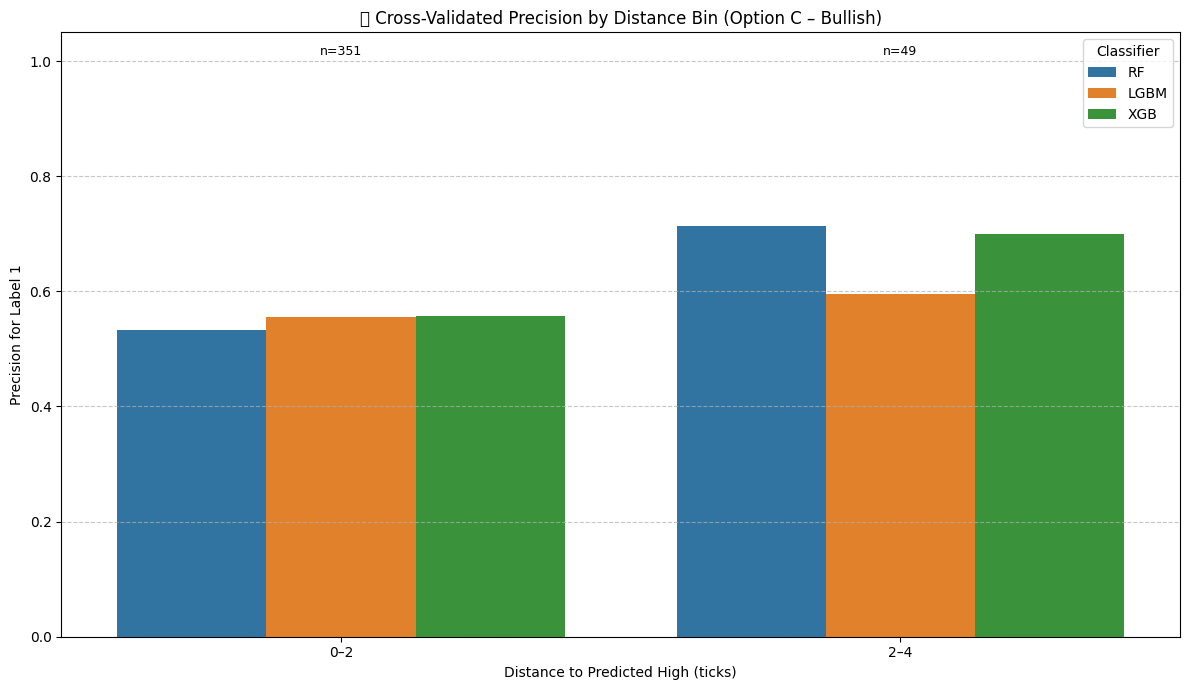


📋 Cross-Validated Precision (Label 1) by Distance Bin:


Model,LGBM,RF,XGB,Sample_Count
Bin,,,,
0–2,0.556,0.534,0.557,351
2–4,0.596,0.714,0.700,49


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("🎯 Cross-Validated Precision by Distance Bin Analysis – Option C (Bullish)\n")

# Combine train and test sets
X_bullish_c = pd.concat([X_train_bullish_goal_c, X_test_bullish_goal_c])
y_bullish_c = pd.concat([y_train_bullish_goal_c, y_test_bullish_goal_c])

# Get indices and filtered meta
all_indices_c = X_bullish_c.index
filtered_meta_c = trainer_c.x_test_with_meta.loc[trainer_c.x_test_with_meta.index.isin(all_indices_c)]

# Rename and attach price data
meta_prices_c = filtered_meta_c[["Close", "Predicted_High"]].rename(columns={
    "Close": "Price_Close",
    "Predicted_High": "Price_Predicted_High"
})
df_bullish_cv_c = X_bullish_c.copy()
df_bullish_cv_c["True_Label"] = y_bullish_c.values
df_bullish_cv_c = df_bullish_cv_c.join(meta_prices_c, how="inner")

# Add distance and bin
df_bullish_cv_c["distance"] = df_bullish_cv_c["Price_Predicted_High"] - df_bullish_cv_c["Price_Close"]
bins = [-float("inf"), 0, 2, 4, 6, 8, float("inf")]
labels = ["<0", "0–2", "2–4", "4–6", "6–8", "8+"]
df_bullish_cv_c["distance_bin"] = pd.cut(df_bullish_cv_c["distance"], bins=bins, labels=labels)

# Bin distribution
print("📊 Distance Bin Distribution:")
bin_counts = df_bullish_cv_c["distance_bin"].value_counts().sort_index()
for bin_label, count in bin_counts.items():
    percent = count / len(df_bullish_cv_c) * 100
    print(f"  {bin_label}: {count} samples ({percent:.1f}%)")

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Models
models = {
    "RF": RandomForestClassifier(random_state=42),
    "LGBM": LGBMClassifier(random_state=42),
    "XGB": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Cross-validation loop
cv_precision_by_bin_c = []
print("\n🔁 Running cross-validation by distance bin...")

for bin_label in labels:
    bin_data = df_bullish_cv_c[df_bullish_cv_c["distance_bin"] == bin_label]
    
    if len(bin_data) < 10:
        print(f"  ⚠️ Skipping bin {bin_label} - insufficient samples ({len(bin_data)})")
        continue
    
    print(f"  Processing bin {bin_label} ({len(bin_data)} samples)")
    X_bin = bin_data.drop(["True_Label", "distance", "distance_bin", "Price_Close", "Price_Predicted_High"], axis=1, errors='ignore')
    y_bin = bin_data["True_Label"]
    
    for model_name, model in models.items():
        all_true, all_pred = [], []
        
        for train_idx, test_idx in kf.split(X_bin):
            if len(np.unique(y_bin.iloc[train_idx])) < 2 or len(np.unique(y_bin.iloc[test_idx])) < 2:
                continue
            X_train_fold, X_test_fold = X_bin.iloc[train_idx], X_bin.iloc[test_idx]
            y_train_fold, y_test_fold = y_bin.iloc[train_idx], y_bin.iloc[test_idx]
            
            model.fit(X_train_fold, y_train_fold)
            y_pred_fold = model.predict(X_test_fold)
            
            all_true.extend(y_test_fold)
            all_pred.extend(y_pred_fold)
        
        if len(all_true) > 0 and 1 in all_true:
            prec = precision_score(all_true, all_pred, pos_label=1, zero_division=0)
            cv_precision_by_bin_c.append({
                "Bin": bin_label,
                "Model": model_name,
                "Precision_1": prec,
                "Count": len(bin_data)
            })
            print(f"    {model_name} - Precision: {prec:.3f} (from {len(all_true)} cross-validated samples)")

# DataFrame and Plot
df_cv_precision_by_distance_c = pd.DataFrame(cv_precision_by_bin_c)

if not df_cv_precision_by_distance_c.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_cv_precision_by_distance_c, x="Bin", y="Precision_1", hue="Model")
    
    for bin_label in df_cv_precision_by_distance_c["Bin"].unique():
        bin_count = df_cv_precision_by_distance_c[df_cv_precision_by_distance_c["Bin"] == bin_label]["Count"].iloc[0]
        bin_index = list(df_cv_precision_by_distance_c["Bin"].unique()).index(bin_label)
        plt.text(bin_index, 1.01, f"n={bin_count}", ha='center', fontsize=9)
    
    plt.title("📊 Cross-Validated Precision by Distance Bin (Option C – Bullish)")
    plt.ylabel("Precision for Label 1")
    plt.xlabel("Distance to Predicted High (ticks)")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Classifier")
    plt.tight_layout()
    plt.show()

    # 📋 Optional pivot table
    pivot_df = df_cv_precision_by_distance_c.pivot(index="Bin", columns="Model", values="Precision_1")
    pivot_df["Sample_Count"] = df_cv_precision_by_distance_c.drop_duplicates("Bin").set_index("Bin")["Count"]
    
    bin_order = {label: i for i, label in enumerate(labels)}
    pivot_df = pivot_df.reset_index()
    pivot_df["bin_order"] = pivot_df["Bin"].map(bin_order)
    pivot_df = pivot_df.sort_values("bin_order").drop("bin_order", axis=1).set_index("Bin")
    
    print("\n📋 Cross-Validated Precision (Label 1) by Distance Bin:")
    display(pivot_df.style.format("{:.3f}", subset=["RF", "LGBM", "XGB"]))
else:
    print("\n⚠️ No results to display - check if bins have sufficient samples")


In [ ]:
# improving using hyper parameter tuning